# 02 – Coherence QA/QC

This notebook validates and visually inspects the UAVSAR coherence GeoTIFFs
produced by the `scripts/slurms/calc_coherence/calc_coherence.py` pipeline.

**Sections**
1. Imports & Setup
2. File Discovery & Sampling
3. Data Validation (reasonable coherence values)
4. Downsampled Preview Plots

## 1. Imports & Setup

In [12]:
import random
from pathlib import Path

import numpy as np
import xarray as xr
import rioxarray  # noqa: F401 – registers the .rio accessor on xarray objects
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Global matplotlib defaults for readable, reasonably sized figures
# ------------------------------------------------------------------
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 9

## 2. File Discovery & Sampling

Set `COHERENCE_DIR` to the root directory that contains the coherence GeoTIFFs
generated by the pipeline (the value you used for `--out_dir` when running
`calc_coherence.py`).  The cell then discovers every `*coh.tif` file
recursively and splits them into two lists:

* **interferometric** – filenames that end with `int_coh.tif`
* **copol** – filenames that end with `copol_coh.tif`

A random subset of up to `SAMPLE_SIZE` files is drawn from each list to keep
the notebook fast on large datasets.

In [13]:
# ---------------------------------------------------------------
# USER CONFIGURATION – update this path before running
# ---------------------------------------------------------------
COHERENCE_DIR = Path("/bsuhome/julialober/scratch/coherence_data/coherence")

# Number of random files to sample from each coherence type
SAMPLE_SIZE = 5

# Fixed random seed for reproducibility; set to None for a fresh random draw
RANDOM_SEED = 42

# ---------------------------------------------------------------
# Discovery – recursively find every *coh.tif produced by the pipeline
# ---------------------------------------------------------------
all_coh_files = sorted(COHERENCE_DIR.rglob("*coh.tif"))
print(f"Total coherence files found: {len(all_coh_files)}")

# Split by coherence type based on the filename suffix convention:
#   interferometric:  ..._int_coh.tif
#   copol:            ..._copol_coh.tif
int_files   = [f for f in all_coh_files if f.name.endswith("int_coh.tif")]
copol_files = [f for f in all_coh_files if f.name.endswith("copol_coh.tif")]

print(f"  Interferometric files : {len(int_files)}")
print(f"  Copol files           : {len(copol_files)}")

# ---------------------------------------------------------------
# Random sampling – draw up to SAMPLE_SIZE from each list
# ---------------------------------------------------------------
rng = random.Random(RANDOM_SEED)

int_sample   = rng.sample(int_files,   min(SAMPLE_SIZE, len(int_files)))
copol_sample = rng.sample(copol_files, min(SAMPLE_SIZE, len(copol_files)))

print(f"\nSampled {len(int_sample)} interferometric and "
      f"{len(copol_sample)} copol files for QA/QC.")

Total coherence files found: 842
  Interferometric files : 698
  Copol files           : 144

Sampled 5 interferometric and 5 copol files for QA/QC.


## 3. Data Validation

The `validate_coherence` function opens each file with `rioxarray` and checks:

| Check | Criterion |
|---|---|
| Value range | All valid (non-NaN) pixels lie **strictly within [0, 1]** |
| NaN / NoData fraction | Reported as a percentage |

A **PASS** is printed when both the minimum and maximum values are within
[0, 1]; a **FAIL** is printed otherwise.

In [14]:
def validate_coherence(file_path: Path) -> bool:
    """
    Validate a single coherence GeoTIFF.

    Opens *file_path* with rioxarray and checks that all valid (non-NaN)
    pixels fall within the physically meaningful coherence range [0, 1].
    Prints a human-readable summary and returns True on pass, False on fail.

    Parameters
    ----------
    file_path : Path
        Path to a coherence GeoTIFF.

    Returns
    -------
    bool
        True if validation passes, False otherwise.
    """
    # Open with rioxarray; squeeze out the band dimension so we work with a
    # 2-D (y, x) array.  masked=True replaces NoData values with NaN.
    da = xr.open_dataarray(file_path, engine="rasterio", masked=True).squeeze()

    # Extract the underlying numpy array and work with NaN-safe functions
    arr = da.values

    total_pixels = arr.size
    nan_pixels   = int(np.sum(np.isnan(arr)))
    valid_pixels = total_pixels - nan_pixels

    nan_pct = (nan_pixels / total_pixels * 100) if total_pixels > 0 else float("nan")

    if valid_pixels > 0:
        # Use nanmin/nanmax so any remaining NaNs are safely ignored
        vmin  = float(np.nanmin(arr))
        vmax  = float(np.nanmax(arr))
        vmean = float(np.nanmean(arr))
    else:
        vmin = vmax = vmean = float("nan")

    # Coherence γ must satisfy 0 ≤ γ ≤ 1
    passed = (not np.isnan(vmin)) and (vmin >= 0.0) and (vmax <= 1.0)
    status = "PASS ✓" if passed else "FAIL ✗"

    print(
        f"[{status}]  {file_path.name}\n"
        f"         Min={vmin:.4f}  Max={vmax:.4f}  Mean={vmean:.4f}  "
        f"NaN={nan_pct:.1f}%  Valid pixels={valid_pixels:,}\n"
    )

    da.close()
    return passed

In [15]:
# ------------------------------------------------------------------
# Run validation on the sampled interferometric coherence files
# ------------------------------------------------------------------
print("=" * 60)
print("INTERFEROMETRIC COHERENCE – VALIDATION")
print("=" * 60)

int_results = [validate_coherence(f) for f in int_sample]

n_pass = sum(int_results)
print(f"Result: {n_pass} / {len(int_results)} files passed.\n")

INTERFEROMETRIC COHERENCE – VALIDATION
[PASS ✓]  stlake_27129_200213_210223_HH_s1_int_coh.tif
         Min=0.0000  Max=1.0000  Mean=0.1799  NaN=9.2%  Valid pixels=21,935,619

[PASS ✓]  fraser_23306_210303_210310_HH_s1_int_coh.tif
         Min=0.0000  Max=1.0000  Mean=0.2936  NaN=58.3%  Valid pixels=34,458,090

[PASS ✓]  dorado_34017_200226_200311_HH_s1_int_coh.tif
         Min=0.0001  Max=1.0000  Mean=0.5374  NaN=44.4%  Valid pixels=26,399,866

[PASS ✓]  irnton_01406_210303_210310_HH_s1_int_coh.tif
         Min=0.0001  Max=1.0000  Mean=0.2877  NaN=38.5%  Valid pixels=27,094,956

[PASS ✓]  irnton_01406_210115_210322_HH_s1_int_coh.tif
         Min=0.0000  Max=1.0000  Mean=0.4900  NaN=0.0%  Valid pixels=44,035,310

Result: 5 / 5 files passed.



In [5]:
# ------------------------------------------------------------------
# Run validation on the sampled copol coherence files
# ------------------------------------------------------------------
print("=" * 60)
print("COPOL COHERENCE – VALIDATION")
print("=" * 60)

copol_results = [validate_coherence(f) for f in copol_sample]

n_pass = sum(copol_results)
print(f"Result: {n_pass} / {len(copol_results)} files passed.")

COPOL COHERENCE – VALIDATION
[PASS ✓]  lowman_05208_210203_HV-VH_s1_copol_coh.tif
         Min=0.0000  Max=1.0000  Mean=0.8827  NaN=54.5%  Valid pixels=30,514,390

[PASS ✓]  irnton_01406_200212_HV-VH_s1_copol_coh.tif
         Min=0.0002  Max=1.0000  Mean=0.8143  NaN=38.5%  Valid pixels=27,094,466

[PASS ✓]  fraser_05209_210310_HV-VH_s1_copol_coh.tif
         Min=0.0000  Max=1.0000  Mean=0.8681  NaN=60.4%  Valid pixels=31,539,124

[PASS ✓]  stlake_27129_210316_HV-VH_s1_copol_coh.tif
         Min=0.0000  Max=1.0000  Mean=0.8546  NaN=9.3%  Valid pixels=21,935,307

[PASS ✓]  fraser_05209_210127_HV-VH_s1_copol_coh.tif
         Min=0.0000  Max=1.0000  Mean=0.8528  NaN=60.4%  Valid pixels=31,538,867

Result: 5 / 5 files passed.


## 4. Downsampled Preview Plots

Loading full-resolution GeoTIFFs into a notebook can crash the kernel on large
scenes.  `plot_coherence_sample` therefore **downsamples each raster
immediately after loading** (10× in both spatial dimensions via
`.coarsen(...).mean()`, or plain array slicing as a fallback) before handing
it to Matplotlib.

In [34]:
import re

# Regex that matches the output filename convention produced by calc_coherence.py
# Interferometric: {site}_{flight}_{date1}_{date2}_{pol}_{segment}_int_coh.tif
# Copol:           {site}_{flight}_{date}_HV-VH_{segment}_copol_coh.tif
_TITLE_RE = re.compile(
    r"^(?P<site>[^_]+)"
    r"_(?P<flight>\d+)"
    r"_(?P<dates>[\w-]+_[\w-]+)"
    r"_(?P<pol>[A-Z]{2}(?:-[A-Z]{2})?)"
    r"_(?P<segment>s\d+)"
)


def _make_title(file_path: Path) -> str:
    """Extract metadata from the filename and return a concise subplot title."""
    m = _TITLE_RE.match(file_path.name)
    if m:
        d = m.groupdict()
        return (
            f"{d['site']} | flight {d['flight']}\n"
            f"dates: {d['dates']} | pol: {d['pol']} | seg: {d['segment']}"
        )
    # Fallback: use the bare filename if the pattern doesn't match
    return file_path.name


def plot_coherence_sample(
    file_paths: list,
    title_prefix: str = "",
    coarsen_factor: int = 10,
    ncols: int = 3,
    mask_1s: bool = False,
) -> None:
    """
    Plot a downsampled preview of each coherence GeoTIFF in *file_paths*.

    Each file is opened, **immediately downsampled** by *coarsen_factor* in
    both spatial dimensions, then drawn into a subplot grid.  NaN values are
    rendered as transparent (``set_bad`` on the colormap) so they do not
    interfere with the colour scale.

    Parameters
    ----------
    file_paths : list of Path
        Coherence GeoTIFFs to plot.
    title_prefix : str, optional
        Short prefix prepended to the overall figure title.
    coarsen_factor : int, optional
        Spatial downsampling factor applied in each dimension (default 10).
    ncols : int, optional
        Number of subplot columns (default 3).
    """
    if not file_paths:
        print("No files to plot.")
        return

    nrows = int(np.ceil(len(file_paths) / ncols))
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(ncols * 5, nrows * 4),
        squeeze=False,
    )

    # Colormap with NaN rendered as light grey so invalid pixels are visible
    cmap = plt.cm.viridis.copy()
    cmap.set_bad(color="lightgrey")

    for idx, fpath in enumerate(file_paths):
        ax = axes[idx // ncols][idx % ncols]

        # -----------------------------------------------------------------
        # Load & downsample
        # Prefer xarray coarsen so coordinate information is preserved; fall
        # back to plain numpy slicing if the array is too small to coarsen.
        # -----------------------------------------------------------------
        da = (
            xr.open_dataarray(fpath, engine="rasterio", masked=True)
            .squeeze()  # drop the band dimension
        )

        if mask_1s : 
            da = xr.where(da == 1, np.nan, da)

        # Attempt coarsen; if the dimension is smaller than coarsen_factor
        # xarray will raise, so we fall back to slicing.
        try:
            da_ds = (
                da
                .coarsen(x=coarsen_factor, y=coarsen_factor, boundary="trim")
                .mean()
            )
        except Exception:
            # Fallback: plain numpy slicing (no coordinate update needed for display)
            da_ds = da.isel(
                x=slice(None, None, coarsen_factor),
                y=slice(None, None, coarsen_factor),
            )

        # Extract values; NaNs from masked raster are preserved as-is
        arr = da_ds.values

        # -----------------------------------------------------------------
        # Plot
        # -----------------------------------------------------------------
        im = ax.imshow(
            arr,
            vmin=0, vmax=1,
            cmap=cmap,
            origin="upper",
            interpolation="nearest",
        )
        ax.set_title(_make_title(fpath), fontsize=8)
        ax.axis("off")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="coherence")

        da.close()

    # Hide any unused subplot axes
    for idx in range(len(file_paths), nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.suptitle(
        f"{title_prefix} coherence – downsampled ×{coarsen_factor} preview",
        fontsize=12,
        y=1.01,
    )
    plt.tight_layout()
    plt.show()

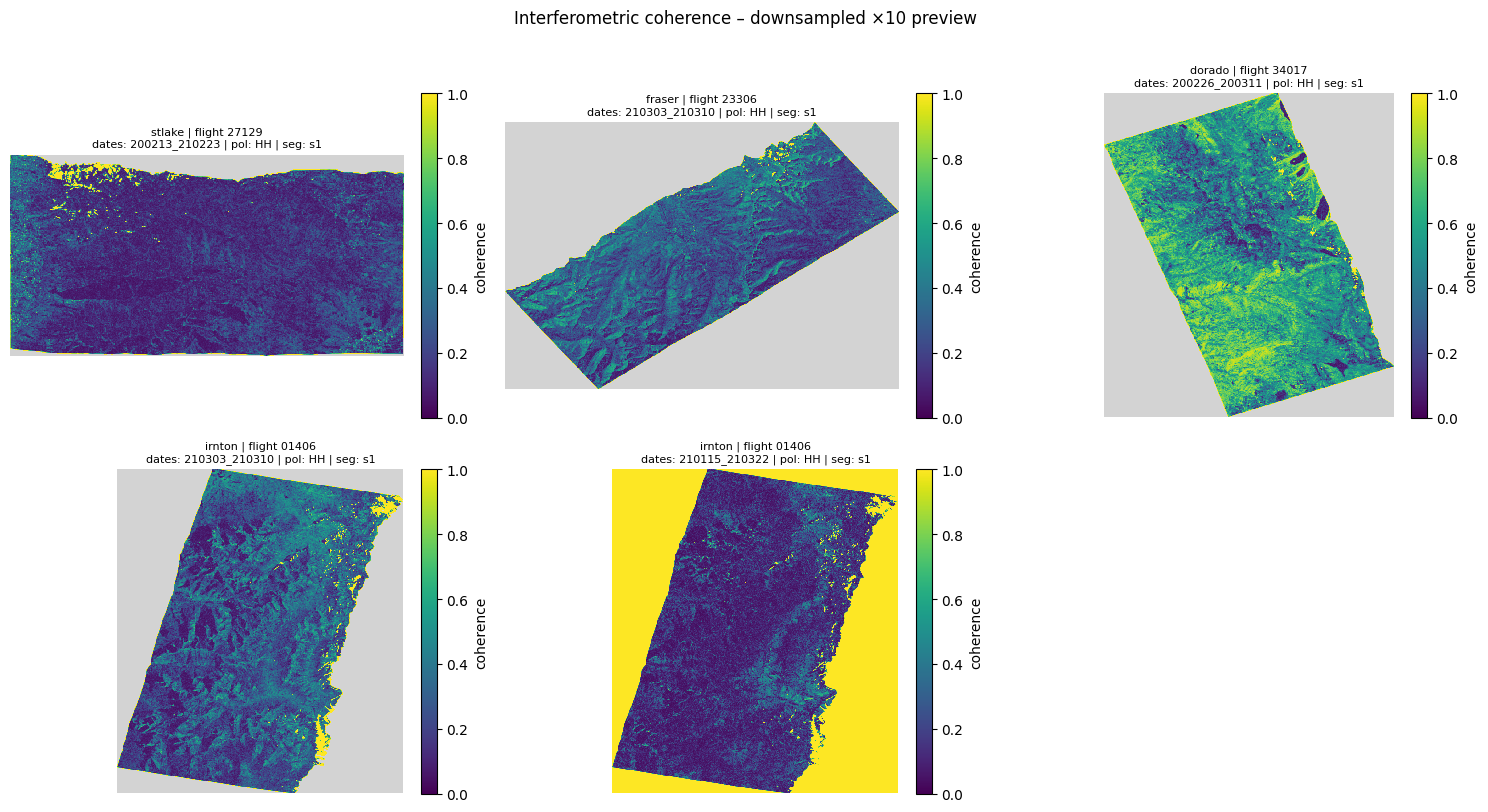

In [7]:
# ------------------------------------------------------------------
# Plot the sampled interferometric coherence files
# ------------------------------------------------------------------
plot_coherence_sample(int_sample, title_prefix="Interferometric")

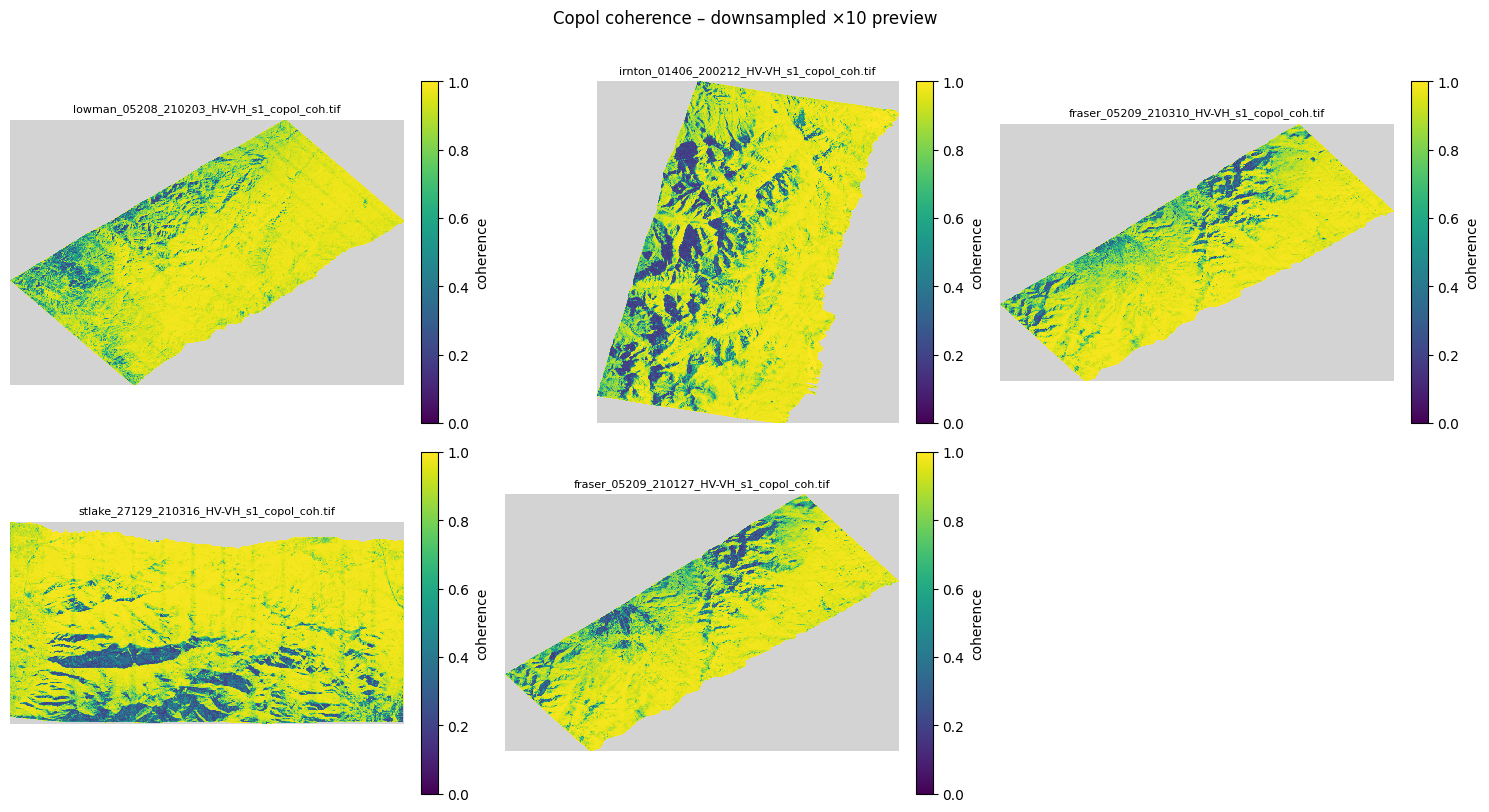

In [8]:
# ------------------------------------------------------------------
# Plot the sampled copol coherence files
# ------------------------------------------------------------------
plot_coherence_sample(copol_sample, title_prefix="Copol")

### Summarize the files



In [9]:
import re
import pandas as pd
from pathlib import Path

def parse_uavsar_filename(filename: str) -> dict:
    """
    Parses a UAVSAR filename to extract metadata using regex.
    """
    metadata = {
        'flight_path': None, 'flight_num': None, 'date_reference': None,
        'date_secondary': pd.NA, 'polarization': None, 'segment': None
    }
    try:
        path_match = re.match(r'^([a-zA-Z0-9\-]+)_', filename)
        if path_match: metadata['flight_path'] = path_match.group(1)
            
        num_match = re.search(r'_(\d{5})_', filename)
        if num_match: metadata['flight_num'] = num_match.group(1)
            
        dates = re.findall(r'(?<=_)\d{6}(?=_|\.)', filename)
        if len(dates) >= 1: metadata['date_reference'] = dates[0]
        if len(dates) >= 2: metadata['date_secondary'] = dates[1]
            
        pol_match = re.search(r'(?<=[_\d])([HV]{2}(?:-[HV]{2})?)_', filename)
        if pol_match: metadata['polarization'] = pol_match.group(1)
            
        seg_match = re.search(r'_(s\d+)_', filename)
        if seg_match: metadata['segment'] = seg_match.group(1)
    except Exception as e:
        print(f"Regex parsing failed for {filename}: {e}")
        
    return metadata

def build_efficient_census(rules_dict: dict) -> pd.DataFrame:
    """
    Builds a file census using a single-pass directory traversal.
    """
    records = []
    
    # 1. Identify unique directories to avoid redundant deep filesystem traversals
    unique_dirs = set(rule['dir'] for rule in rules_dict.values())
    
    for base_dir_str in unique_dirs:
        base_path = Path(base_dir_str)
        
        if not base_path.exists():
            print(f"Directory not found: {base_path}. Skipping.")
            continue
            
        try:
            # Single-pass traversal of this directory
            for filepath in base_path.rglob('*'):
                if filepath.is_dir() or filepath.name.startswith('.'):
                    continue
                
                filename = filepath.name
                
                # 2. Evaluate file against our rules to classify it
                matched_type = None
                for file_type, rule in rules_dict.items():
                    if rule['dir'] == base_dir_str and filename.endswith(rule['endswith']):
                        matched_type = file_type
                        break # File type identified, stop checking rules
                
                # If the file matches a rule, extract metadata and store
                if matched_type:
                    meta = parse_uavsar_filename(filename)
                    records.append({
                        'filename': filename,
                        'file_type': matched_type,
                        'flight_path': meta['flight_path'],
                        'flight_num': meta['flight_num'],
                        'date_reference': meta['date_reference'],
                        'date_secondary': meta['date_secondary'],
                        'polarization': meta['polarization'],
                        'segment': meta['segment'],
                        'absolute_path': str(filepath)
                    })
        except PermissionError:
            print(f"Permission denied accessing contents of {base_path}")
        except Exception as e:
            print(f"Unexpected I/O error in {base_path}: {e}")

    return pd.DataFrame(records)



In [10]:

ddir = '/bsuhome/julialober/scratch/coherence_data/'

input_rules = {
    'int_pair':       {'dir': f'{ddir}/coherence',   'endswith': 'int_coh.tif'},
    'copol_pair':     {'dir': f'{ddir}coherence',   'endswith': 'copol_coh.tif'},
    'raw_slc':        {'dir': f'{ddir}/uavsar_slcs', 'endswith': '.slc'},
    'ann_slc':        {'dir': f'{ddir}/uavsar_slcs', 'endswith': '.ann'},
    'lkv':            {'dir': f'{ddir}/uavsar_slcs', 'endswith': '.lkv'},
    'llh':            {'dir': f'{ddir}/uavsar_slcs', 'endswith': '.llh'},
    'geo_slc':        {'dir': f'{ddir}/uavsar_geoslcs', 'endswith': '.complex.tif'},
}

# 1. Build the DataFrame
census_df = build_efficient_census(input_rules)

# 2. Verify sorting by file type works properly
if not census_df.empty:
    display(census_df.groupby('file_type').size().reset_index(name='count'))
else:
    print("DataFrame is empty. Verify your directory paths.")

,file_type,count
0,ann_slc,541
1,copol_pair,144
2,geo_slc,624
3,int_pair,698
4,lkv,30
5,llh,30
6,raw_slc,806


In [11]:
print(census_df.loc[census_df['polarization'] == 'VV'])

                                               filename file_type flight_path  \
11       lowman_05208_20011_002_200221_L090VV_01_BU.ann   ann_slc      lowman   
12    lowman_05208_21015_009_210303_L090VV_01_BU_s1_...   raw_slc      lowman   
14    lowman_05208_20002_006_200131_L090VV_01_BU_s2_...   raw_slc      lowman   
23    lowman_05208_21012_004_210210_L090VV_01_BU_s1_...   raw_slc      lowman   
28    lowman_05208_21021_007_210322_L090VV_01_BU_s1_...   raw_slc      lowman   
...                                                 ...       ...         ...   
2008  irnton_01406_21005_001_210121_L090VV_01_BU_s1_...   geo_slc      irnton   
2009  irnton_01406_21012_005_210211_L090VV_01_BU_s1_...   geo_slc      irnton   
2022  uticam_21003_21002_003_210115_L090VV_01_BC_s1_...   geo_slc      uticam   
2028  uticam_21003_21004_002_210120_L090VV_01_BC_s1_...   geo_slc      uticam   
2029  uticam_21003_21013_003_210223_L090VV_01_BC_s1_...   geo_slc      uticam   

     flight_num date_refere

In [16]:
# Define preferred column order for easy comparison
cols = [c for c in ['raw_slc', 
                    'geo_slc', 
                    'ann_slc', 
                    'lkv', 
                    'llh', 
                    'int_pair', 
                    'copol_pair'] if c in census_df['file_type'].values]
summary_df = census_df.pivot_table(index=['flight_path', 'flight_num'], 
                                   columns='file_type', 
                                   aggfunc='size', 
                                   fill_value=0)[cols]
display(summary_df.join(census_df.groupby(['flight_path', 'flight_num'])[['polarization', 'segment']].nunique().add_prefix('unique_')))

raw_slc  geo_slc  ann_slc  lkv  llh  int_pair  \
flight_path flight_num                                                  
alamos      35915             8        8        8    1    1         1   
donner      03904            16       16       16    1    1         6   
dorado      34017            60       40       20    3    3        20   
fraser      05209            56       56       56    1    1        78   
            23306            24       24       24    1    1        15   
grmesa      09305             5        5        5    1    1        10   
            27416            12       12       12    1    1        66   
irnton      01406            56       56       56    1    1        91   
lowman      05208           125       82       41    4    4        90   
            23205           156       89       67    3    3       156   
peeler      13711            16       16       16    1    1         6   
            31619            16       16       16    1    1         6   
rockmt      14107            48       48       48    1    1        66   
            32109            32       32       32    1    1         0   
sierra      17305            40       20       20    2    2        10   
            35402            40       20       20    2    2        10   
silver      16718            16       16       16    1    1         6   
            34715            12       12       12    1    1         3   
stlake      27129            44       44       44    1    1        55   
uticam      21003            24       12       12    2    2         3   

                        copol_pair  unique_polarization  unique_segment  
flight_path flight_num                                                   
alamos      35915                2                    5               1  
donner      03904                4                    5               1  
dorado      34017               10                    5               3  
fraser      05209               13                    5               1  
            23306                6                    5               1  
grmesa      09305                0                    1               1  
            27416                0                    1               1  
irnton      01406               14                    5               1  
lowman      05208               20                    5               3  
            23205               16                    5               3  
peeler      13711                4                    5               1  
            31619                4                    5               1  
rockmt      14107               12                    5               1  
            32109                8                    5               1  
sierra      17305                5                    5               2  
            35402                5                    5               2  
silver      16718                4                    5               1  
            34715                3                    5               1  
stlake      27129               11                    5               1  
uticam      21003                3                    5               2

In [17]:
# Extract dates, drop missing/duplicates, and parse YYMMDD to YYYY-MM-DD
all_dates = pd.concat([
    census_df[['flight_path', 'flight_num', 'date_reference']].rename(columns={'date_reference': 'date'}),
    census_df[['flight_path', 'flight_num', 'date_secondary']].rename(columns={'date_secondary': 'date'})
]).dropna().drop_duplicates()
all_dates['date'] = pd.to_datetime(all_dates['date'], format='%y%m%d').dt.strftime('%Y-%m-%d')

# Date Consistency Check
# print("--- Date Consistency Check per Flight Path ---")
# display(all_dates.groupby(['flight_path', 'flight_num'])['date'].apply(frozenset).groupby('flight_path').nunique().eq(1).rename("All Dates Match").to_frame())

# Temporal Grid
all_dates['year'] = all_dates['date'].str[:4]

# 2. Iterate through each unique year and display its own grid
for year in sorted(all_dates['year'].unique()):
    print(f"\n--- Temporal Acquisition Grid: {year} ---")
    
    # Filter for the year, assign the marker, pivot, and fill NaNs
    yearly_grid = (all_dates[all_dates['year'] == year]
                   .assign(Acquired='█')
                   .pivot(index=['flight_path', 'flight_num'], columns='date', values='Acquired')
                   .fillna('-'))
    
    display(yearly_grid)


--- Temporal Acquisition Grid: 2019 ---


,date,2019-12-20
flight_path,flight_num,
lowman,23205,█



--- Temporal Acquisition Grid: 2020 ---


date                   2020-01-31 2020-02-01 2020-02-12 2020-02-13 2020-02-19  \
flight_path flight_num                                                          
alamos      35915               -          -          █          -          -   
donner      03904               █          -          -          -          █   
dorado      34017               █          -          █          -          █   
fraser      05209               -          -          █          -          █   
grmesa      09305               -          █          █          -          █   
            27416               -          █          █          -          █   
irnton      01406               -          -          █          -          █   
lowman      05208               █          -          -          █          -   
            23205               █          -          -          █          -   
peeler      13711               -          -          █          -          █   
            31619               -          -          █          -          █   
rockmt      14107               -          -          █          -          █   
            32109               -          -          █          -          █   
sierra      17305               █          -          █          -          █   
            35402               █          -          █          -          █   
silver      16718               █          -          -          █          -   
            34715               █          -          -          -          -   
stlake      27129               █          -          -          █          -   

date                   2020-02-21 2020-02-26 2020-03-11 2020-03-12  
flight_path flight_num                                              
alamos      35915               -          █          -          -  
donner      03904               -          █          █          -  
dorado      34017               -          █          █          -  
fraser      05209               -          █          -          █  
grmesa      09305               -          █          -          █  
            27416               -          █          -          █  
irnton      01406               -          █          -          █  
lowman      05208               █          -          █          -  
            23205               █          -          █          -  
peeler      13711               -          █          -          █  
            31619               -          █          -          █  
rockmt      14107               -          █          -          █  
            32109               -          -          -          █  
sierra      17305               -          █          █          -  
            35402               -          █          █          -  
silver      16718               █          -          █          -  
            34715               █          -          █          -  
stlake      27129               █          -          -          █


--- Temporal Acquisition Grid: 2021 ---


date                   2021-01-15 2021-01-20 2021-01-21 2021-01-27 2021-01-28  \
flight_path flight_num                                                          
fraser      05209               █          █          -          █          -   
            23306               -          -          -          █          -   
grmesa      27416               -          -          -          █          -   
irnton      01406               █          -          █          -          █   
lowman      05208               -          -          -          -          -   
            23205               █          █          -          █          -   
rockmt      14107               █          █          -          █          -   
            32109               -          -          -          █          -   
stlake      27129               -          -          -          -          -   
uticam      21003               █          █          -          -          -   

date                   2021-02-03 2021-02-04 2021-02-10 2021-02-11 2021-02-23  \
flight_path flight_num                                                          
fraser      05209               █          -          -          -          █   
            23306               █          -          -          -          -   
grmesa      27416               █          -          █          -          -   
irnton      01406               -          █          -          █          █   
lowman      05208               █          -          █          -          -   
            23205               █          -          █          -          █   
rockmt      14107               -          -          -          -          █   
            32109               █          -          -          -          -   
stlake      27129               █          -          █          -          █   
uticam      21003               -          -          -          -          █   

date                   2021-03-03 2021-03-10 2021-03-16 2021-03-22  
flight_path flight_num                                              
fraser      05209               █          █          █          █  
            23306               █          █          █          █  
grmesa      27416               █          █          █          █  
irnton      01406               █          █          █          █  
lowman      05208               █          █          █          █  
            23205               █          █          █          █  
rockmt      14107               █          █          █          █  
            32109               █          █          -          █  
stlake      27129               █          █          █          █  
uticam      21003               -          -          -          -

# Plot a coherence matrix

In [18]:
import sys
import os

scripts_dir = (os.path.dirname(os.getcwd()) + '/scripts/')
sys.path.append(scripts_dir)

%load_ext autoreload
%autoreload 2
from plotting import plot_tifs_grid, plot_coherence_matrix
from coherence import calc_coherence, calc_coherence_matrix

import tifffile as tif

In [19]:
COHERENCE_DIR = Path("/bsuhome/julialober/scratch/coherence_data/coherence")

lowman = sorted(COHERENCE_DIR.rglob("lowman_05208*s2*int_coh.tif"))
len(lowman)

45

In [20]:
stack = [tif.imread(f) for f in lowman]

In [30]:
stack_clean = [np.where(s == 1, np.nan, s) for s in stack]
print(stack_clean[2])
# s = stack[1]
# print(s)
# np.where(s == 1, np.nan, s)

[[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]]


In [28]:
input_rules = {
    'int_pair':       {'dir': f'{COHERENCE_DIR}/lowman/05208/',   'endswith': 'int_coh.tif'},
}
lowman_meta = build_efficient_census(input_rules)
lowman_meta = lowman_meta[lowman_meta['segment'] == 's2']

# get dates 
lowman_dates = pd.concat([
    lowman_meta[['flight_path', 'flight_num', 'date_reference']].rename(columns={'date_reference': 'date'}),
    lowman_meta[['flight_path', 'flight_num', 'date_secondary']].rename(columns={'date_secondary': 'date'})
]).dropna().drop_duplicates()
lowman_dates['date'] = pd.to_datetime(lowman_dates['date'], format='%y%m%d').dt.strftime('%Y-%m-%d')

lowman_meta.head()


,filename,file_type,flight_path,flight_num,date_reference,date_secondary,polarization,segment,absolute_path
4,lowman_05208_200221_200311_HH_s2_int_coh.tif,int_pair,lowman,05208,200221,200311,HH,s2,/bsuhome/julialober/scratch/coherence_data/coh...
6,lowman_05208_210303_210310_HH_s2_int_coh.tif,int_pair,lowman,05208,210303,210310,HH,s2,/bsuhome/julialober/scratch/coherence_data/coh...
9,lowman_05208_210210_210303_HH_s2_int_coh.tif,int_pair,lowman,05208,210210,210303,HH,s2,/bsuhome/julialober/scratch/coherence_data/coh...
10,lowman_05208_200131_210310_HH_s2_int_coh.tif,int_pair,lowman,05208,200131,210310,HH,s2,/bsuhome/julialober/scratch/coherence_data/coh...
11,lowman_05208_210310_210316_HH_s2_int_coh.tif,int_pair,lowman,05208,210310,210316,HH,s2,/bsuhome/julialober/scratch/coherence_data/coh...


In [31]:
print(len(stack))
print(len(lowman_dates))
matrix = calc_coherence_matrix(stack_clean, num_scenes=len(lowman_dates))

45
10


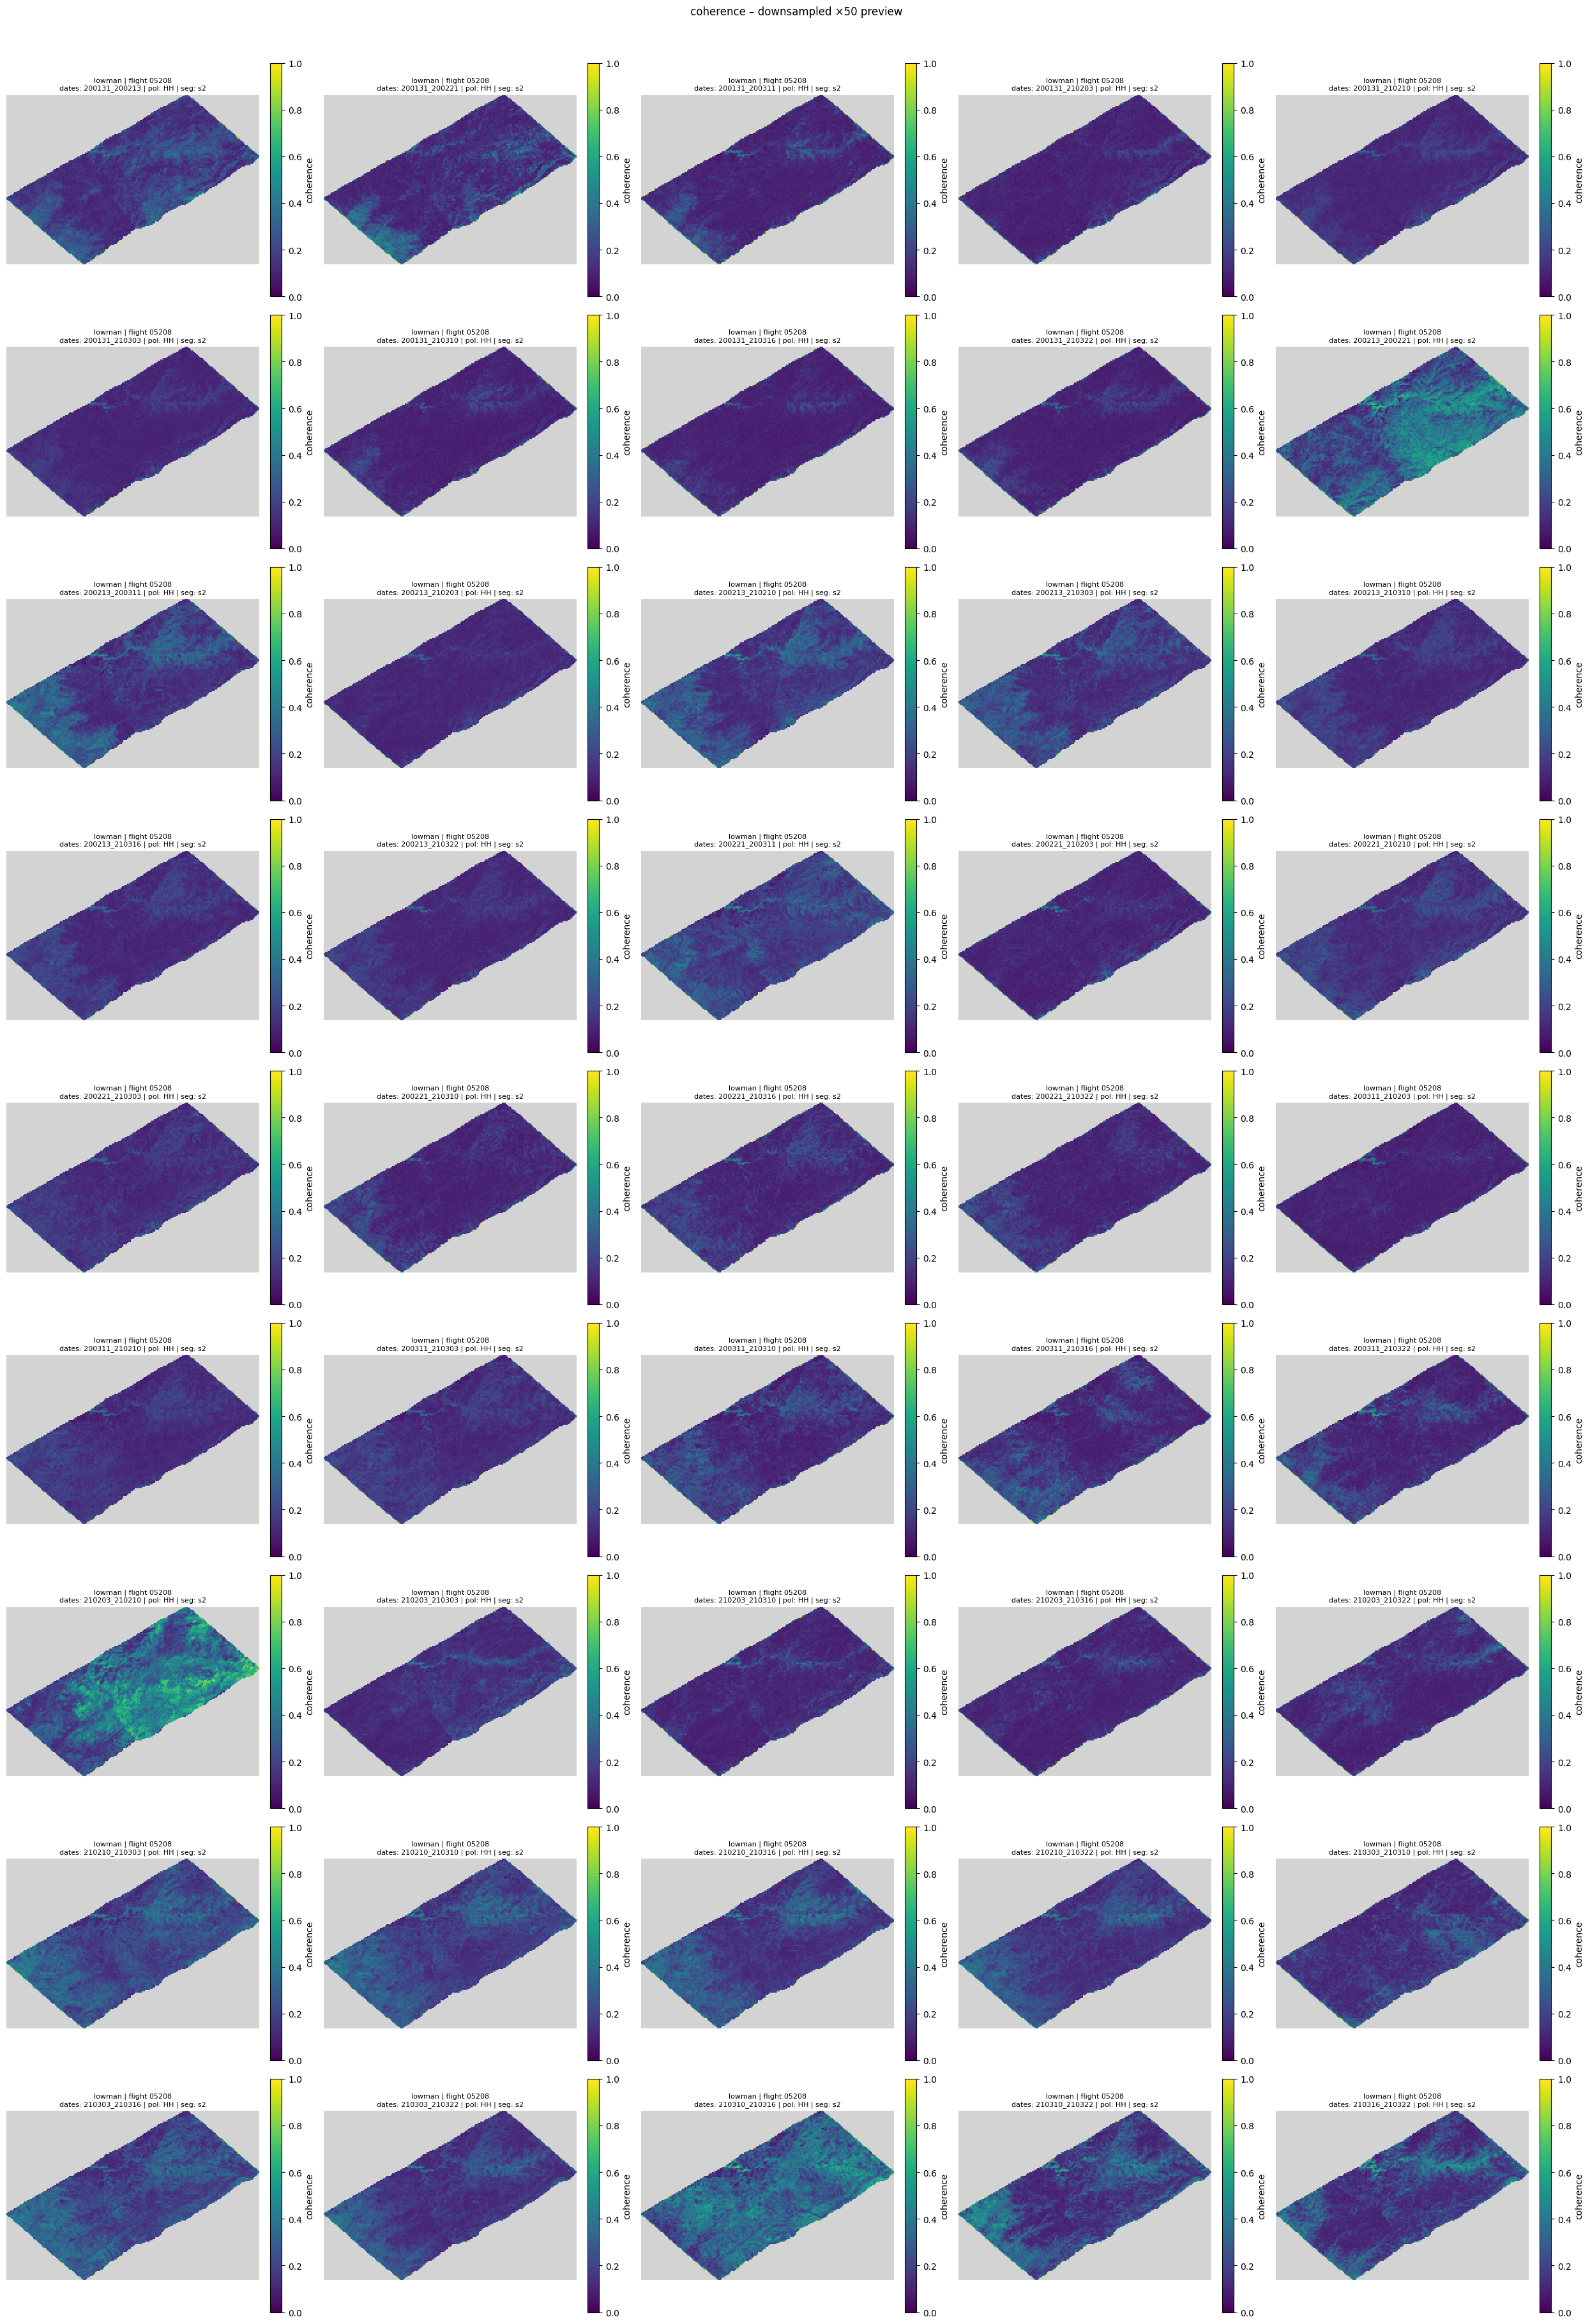

In [35]:
plot_coherence_sample(lowman,
                      coarsen_factor=50,
                      ncols=5,
                      mask_1s=True,
                      )

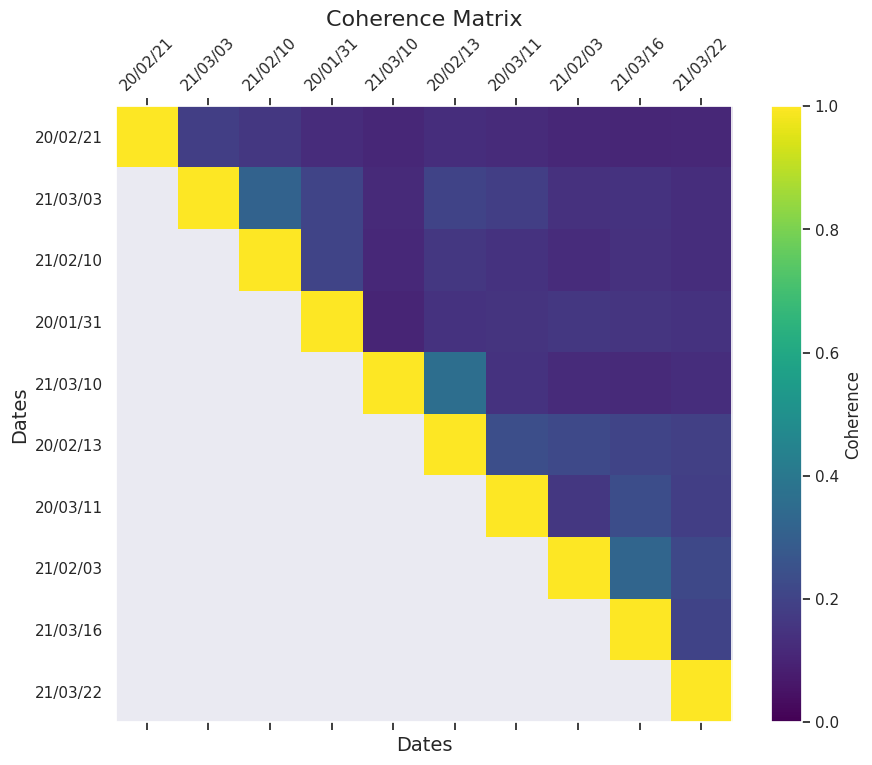

In [38]:
from seaborn import set_theme
set_theme()
plt, ax = plot_coherence_matrix(matrix, lowman_dates['date'])